<a href="https://colab.research.google.com/github/oluwapelumi1/ACCESS-SAP-DATA-Science-Track/blob/main/Mini%20Project%20Part%202%20%E2%80%94%20End-to-End%20Data%20Preparation%20(New%20Dataset)%3A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini Project**
# **Part 2 — End-to-End Data Preparation (New Dataset):**

---




##**OBJECTIVES:**

using the datasets:[Housing Dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices)


*   Initial Data Inspection
    >Check shape, columns, data types


    >>Identify missing values (if any)


*   Data Cleaning
    >Handle missing values appropriately (if any)

    >>Fix incorrect data types

    >>>Remove duplicates (if any)
*   Exploratory Data Analysis (EDA)
    >Perform basic univariate and bivariate analysis

    >>Create at least 2 visualizations

    >>>Write short insights (1–2 sentences each)


*   Feature Engineering, Scaling and Encoding
    >Create at least 2 new features

    >>Identify the columns that would be scales and those that would be encoded.
*   Model Recommendation.
    >Identify a target variable


    >>State the problem type and recommend what type of model will be used (regression, classification or clustering)




In [1]:
#Import Necesssary Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Make plots appear in notebook
%matplotlib inline

#Suppress warnings for Cleaner output
import warnings
warnings.filterwarnings('ignore')


In [2]:
#Load the dataset
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/housing.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Initial Data Inspection**

* Check shape, columns, data types

* Identify missing values (if any)

In [3]:
#inspecting the data

# - head(): first 5 rows of this dataset
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
#inspect the last five rows
df.tail()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [5]:
#to get specific rows using their label positions
df.iloc[8000:10000]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
8000,-118.13,33.85,36.0,2110.0,416.0,1128.0,403.0,4.6019,208400.0,<1H OCEAN
8001,-118.13,33.85,36.0,1885.0,391.0,1049.0,405.0,3.5500,212800.0,<1H OCEAN
8002,-118.14,33.86,36.0,1774.0,348.0,934.0,333.0,4.8571,203300.0,<1H OCEAN
8003,-118.14,33.86,36.0,1703.0,325.0,845.0,308.0,5.0106,210800.0,<1H OCEAN
8004,-118.10,33.85,28.0,2825.0,470.0,1352.0,469.0,5.2639,242000.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
9995,-121.03,39.14,10.0,3138.0,524.0,1275.0,511.0,4.0775,164500.0,INLAND
9996,-121.07,39.13,8.0,4839.0,832.0,1977.0,762.0,4.0848,155900.0,INLAND
9997,-121.05,39.11,7.0,2767.0,423.0,1143.0,382.0,3.6333,170200.0,INLAND
9998,-121.04,39.08,8.0,2870.0,526.0,1307.0,451.0,3.4630,201700.0,INLAND


In [6]:
#inspect the shape
df.shape
print(f"The shape of the dataset is:{df.shape}")

The shape of the dataset is:(20640, 10)


In [7]:
#check the columns
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [8]:
#checking for missing values in the dataset
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [9]:
#inspecting the datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# **Data Cleaning**

* Handle missing values appropriately (if any)

* Fix incorrect data types

* Remove duplicates (if any)

In [10]:
df.head(7000)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
6995,-118.03,33.96,37.0,1180.0,256.0,614.0,242.0,3.1170,164600.0,<1H OCEAN
6996,-118.03,33.95,34.0,1882.0,428.0,1034.0,375.0,3.6509,173200.0,<1H OCEAN
6997,-118.03,33.95,37.0,1772.0,321.0,934.0,326.0,4.1471,177800.0,<1H OCEAN
6998,-118.04,33.95,36.0,2722.0,515.0,1390.0,486.0,3.8214,178500.0,<1H OCEAN


In [11]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [12]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [13]:
# total_bedrooms  - 207 missing
# Decision: Can't analyze spending without total_bedrooms . Drop these rows.
df = df.dropna(subset=['total_bedrooms'])

In [14]:
df_clean=df.copy()

In [15]:
# Step 3: Verify
print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"\nRemaining missing values:")
print(df_clean.isnull().sum())



Original shape: (20433, 10)
Cleaned shape: (20433, 10)

Remaining missing values:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [16]:
#checking for duplicate
df_clean.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
20635,False
20636,False
20637,False
20638,False


In [17]:
# Check for duplicate rows
duplicates_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

if duplicates_count > 0:
    # Drop duplicate rows
    df_clean_no_duplicates = df_clean.drop_duplicates()
    print(f"Shape after dropping duplicates: {df_clean_no_duplicates.shape}")
else:
    print("No duplicates found.")
    df_clean_no_duplicates = df_clean.copy()

Number of duplicate rows: 0
No duplicates found.


# **Exploratory Data Analysis (EDA)**

Perform basic univariate and bivariate analysis

Create at least 2 visualizations

Write short insights (1–2 sentences each)**bold text**

In [18]:
df.head() # Display the first few rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# **Univariate Analysis**

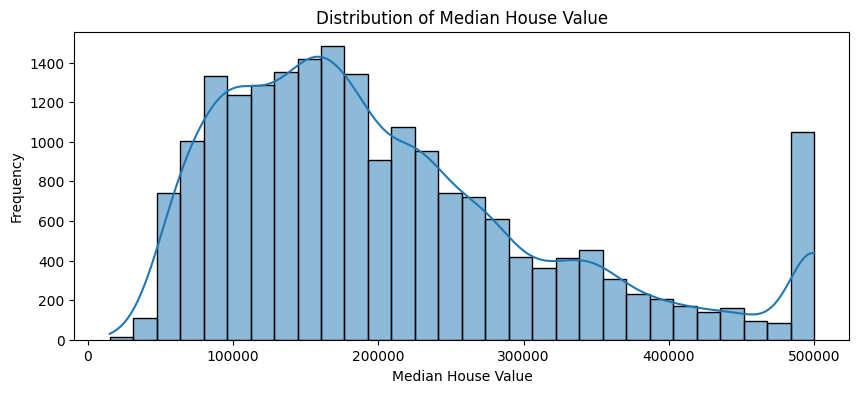

In [19]:
#histogram of the column 'median_house_value'
plt.figure(figsize=(10, 4))
sns.histplot(df['median_house_value'], bins=30, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show();

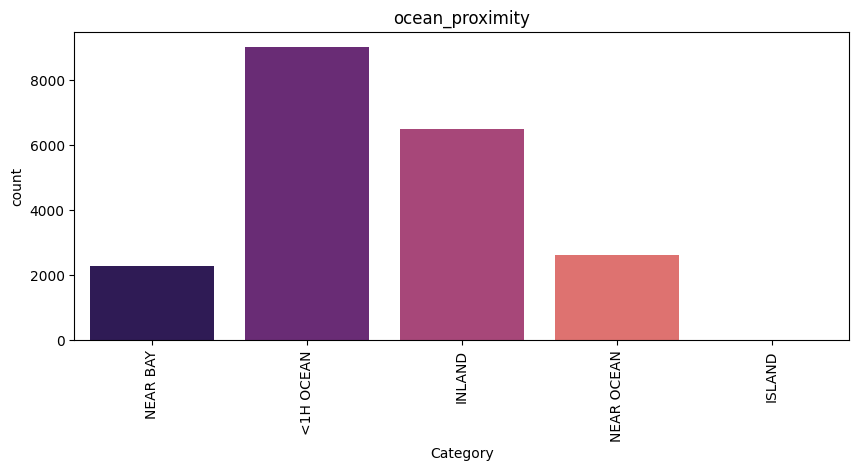

In [20]:
#category column -> distribution
plt.figure(figsize=(10,4))
sns.countplot(x = "ocean_proximity", data = df, palette = "magma")
plt.title("ocean_proximity")
plt.xlabel("Category")
plt.ylabel("count")
plt.xticks(rotation = 90)
plt.show();

# ***Insight***

---



Distribution of Ocean Proximity: The dataset is dominated by properties with '<1H OCEAN' and 'INLAND' proximity, indicating these are the most common types of locations. 'ISLAND' properties are very rare, which could suggest they are a niche or premium category.
ariate analysis:

Distribution of Median House Value: The distribution of median house values is right-skewed, with a majority of houses valued below 300,000 and a significant peak near 300,000 and a significant peak near 500,000. This suggests that while most homes are in the lower to mid-range, there's a considerable number reaching the upper limit of the recorded values.


# **Bivariate Analysis**

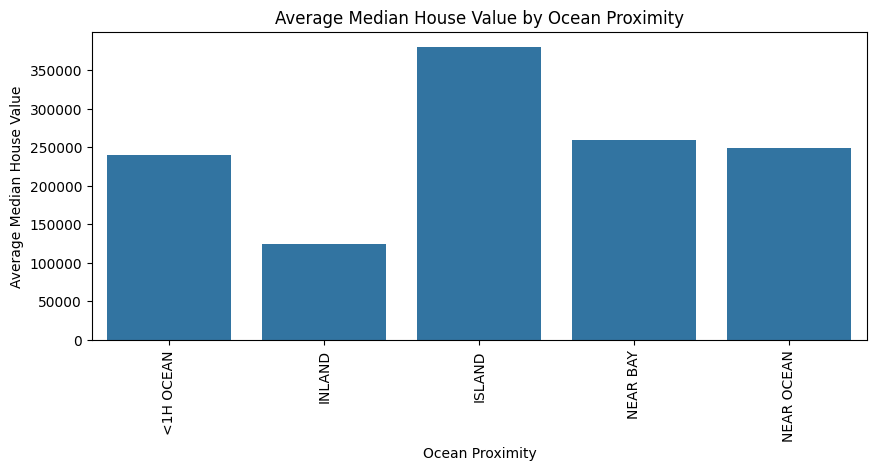

In [21]:
# Average Median House Value by Ocean Proximity
ocean_proximity_value = df.groupby("ocean_proximity")["median_house_value"].mean()
plt.figure(figsize=(10,4))
sns.barplot(x = ocean_proximity_value.index, y = ocean_proximity_value.values)
plt.title("Average Median House Value by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Average Median House Value")
plt.xticks(rotation = 90)
plt.show();

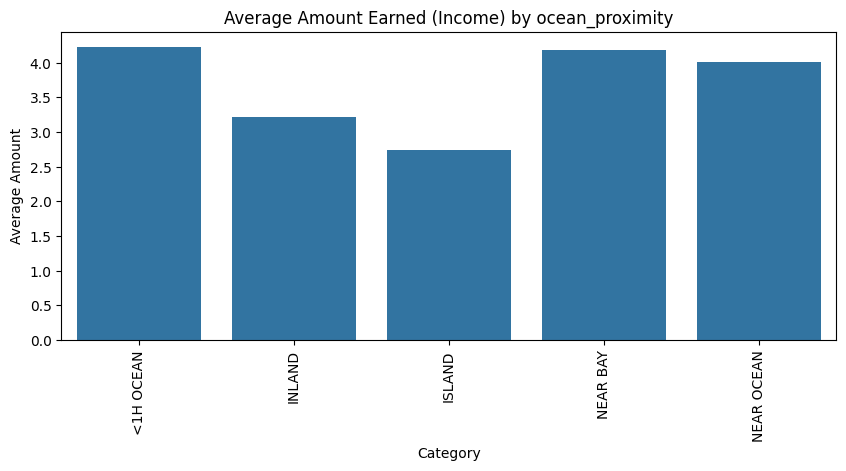

In [22]:

#ocean_proximity by median_income
cat_median_income_2 = df.groupby("ocean_proximity")["median_income"].mean()
plt.figure(figsize = (10,4))
sns.barplot(x = cat_median_income_2.index, y = cat_median_income_2.values)
plt.title("Average Amount Earned (Income) by ocean_proximity")
plt.xlabel("Category")
plt.ylabel("Average Amount")
plt.xticks(rotation = 90)
plt.show();

# ***Insight***

---



Average Median House Value by Ocean Proximity: Properties located near 'ISLAND' have the highest average median house value, followed by 'NEAR BAY' and 'NEAR OCEAN'. 'INLAND' properties show significantly lower average median house values compared to coastal or island areas.
Average Median Income by Ocean Proximity: Areas with &lt;1H OCEAN proximity tend to have the highest average median income, while 'ISLAND' areas surprisingly exhibit the lowest average median income in this dataset.

# **Feature Engineering, Scaling and Encoding**



*   Create at least 2 new features
*   Identify the columns that would be scales and those that would be encoded.





In [23]:
# Remove duplicate rows (keep first occurrence)
df_clean = df_clean.drop_duplicates()


print(f"Shape after removing duplicates: {df_clean.shape}")


Shape after removing duplicates: (20433, 10)


In [24]:
# Create new features relevant to the housing dataset
df_clean['rooms_per_household'] = df_clean['total_rooms'] / df_clean['households']
df_clean['bedrooms_per_room'] = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['population_per_household'] = df_clean['population'] / df_clean['households']

print("New features created:")
print(df_clean[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head())

New features created:
   rooms_per_household  bedrooms_per_room  population_per_household
0             6.984127           0.146591                  2.555556
1             6.238137           0.155797                  2.109842
2             8.288136           0.129516                  2.802260
3             5.817352           0.184458                  2.547945
4             6.281853           0.172096                  2.181467


These features provide more nuanced insights into the property characteristics by normalizing total counts (rooms, bedrooms, population) by the number of households. This often helps in building more robust models. The first few rows of these new features are:

In [25]:
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# **Creating Boolean Flags**

In [26]:
# Flag high-value transactions
df_clean['is_high_value'] = df_clean['median_house_value'] > 10000

# Flag properties that are either <1H OCEAN or INLAND
df_clean['is_coastal_or_inland'] = df_clean['ocean_proximity'].isin(['<1H OCEAN', 'INLAND'])

In [27]:
df_clean.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,is_high_value,is_coastal_or_inland
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467,True,False


# **Creating Aggregated Features**

In [28]:
# Different metrics for each category
category_analysis = df_clean.groupby('ocean_proximity')['median_house_value'].agg([
    ('total_spending', 'sum'),
    ('avg_spending', 'mean'),
    ('max_transaction', 'max'),
    ('min_transaction', 'min'),
    ('num_transactions', 'count'),
    ('median_spending', 'median')
]).reset_index()

category_analysis = category_analysis.sort_values('total_spending', ascending=False)
print(category_analysis)

  ocean_proximity  total_spending   avg_spending  max_transaction  \
0       <1H OCEAN    2.170581e+09  240267.990812         500001.0   
1          INLAND    8.113300e+08  124896.863147         500001.0   
4      NEAR OCEAN    6.544833e+08  249042.355023         500001.0   
3        NEAR BAY    5.885640e+08  259279.292070         500001.0   
2          ISLAND    1.902200e+06  380440.000000         450000.0   

   min_transaction  num_transactions  median_spending  
0          17500.0              9034         215000.0  
1          14999.0              6496         108700.0  
4          22500.0              2628         228750.0  
3          22500.0              2270         233800.0  
2         287500.0                 5         414700.0  


# **Identifying the columns that would be scales and those that would be encoded.**



**Columns that would be scaled**
(Numerical Features): These are continuous numerical features that often benefit from scaling to bring them to a similar range, which helps many machine learning algorithms perform better. Common scaling techniques include StandardScaler or MinMaxScaler.



*  longitude
*  latitude

*   housing_median_age
*   total_rooms

*  total_bedrooms
*  population

*   households
*   median_income

*   rooms_per_household
*   bedrooms_per_room
*   population_per_household


**Columns that would be encoded**(Categorical Features): These are non-numerical features that need to be converted into a numerical representation for machine learning models

*  ocean_proximity (as it's a string/object type)








# **Model Recommendation.**

* Identify a target variable

* State the problem type and recommend what type of model will be used (regression, classification or clustering)

**The target variable for this dataset would be median_house_value.**

  **The median_house_value is a numerical variable,so the problem type is Regression. For this type of problem, For this type of problem, I would recommend using models such as:**
  
* Linear Regression: A simple yet effective baseline.

*  Decision Tree Regressor: Good for capturing non-linear relationships.

* Random Forest Regressor: An ensemble method that often provides higher accuracy and handles complex relationships well.

* Gradient Boosting Regressor (e.g., XGBoost, LightGBM): Powerful ensemble methods known for their high predictive performance.